# 01 — Data Ingestion & Data Quality (German Power, DE-LU)

This notebook runs the Task-1 pipeline end to end and shows the data-quality results.

**Pipeline:** `src/ingest.py` (download) -> `src/transform.py` (clean + align hourly) -> `src/qa.py` (checks + figures).

**Source:** Energy-Charts API (Fraunhofer ISE), public and key-free.

In [1]:
# Make the project root importable so we can use config.py and src/*
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

import config
from src import ingest, transform, qa
print("Market:", config.MARKET_BZN, "| Range:", config.START_DATE, "->", config.END_DATE)

Market: DE-LU | Range: 2023-06-16 -> 2026-06-16


## 1. Ingest
Downloads day-ahead price, generation/load, and cross-border flows. Files are cached in `data/raw/`, so re-running is instant.

In [2]:
ingest.main()


Day-ahead price: already cached at /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/data/raw/price.parquet, skipping.
Public power (generation + load): already cached at /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/data/raw/public_power.parquet, skipping.
Cross-border flows: already cached at /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/data/raw/cbpf.parquet, skipping.

Done. Raw Parquet files written to /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/data/raw


## 2. Transform
Resamples everything to a common **hourly** grid, combines wind onshore+offshore, joins on UTC, and adds a local (Europe/Berlin) timestamp.

In [3]:
df = transform.transform()
df.head()

Merged dataset: 26,328 hourly rows, 6 columns
Columns: ['price_eur_mwh', 'load_mw', 'wind_mw', 'solar_mw', 'net_flow_mw', 'timestamp_local']
Saved to /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/data/processed/dataset.parquet


,price_eur_mwh,load_mw,wind_mw,solar_mw,net_flow_mw,timestamp_local
timestamp_utc,,,,,,
2023-06-15 22:00:00+00:00,126.16,"43,223.35","4,638.30",0.00,7.51,2023-06-16 00:00:00+02:00
2023-06-15 23:00:00+00:00,121.62,"41,548.32","4,262.10",0.00,7.85,2023-06-16 01:00:00+02:00
2023-06-16 00:00:00+00:00,115.59,"40,735.82","4,106.95",0.00,8.60,2023-06-16 02:00:00+02:00
2023-06-16 01:00:00+00:00,112.70,"41,161.85","3,951.45",0.00,8.99,2023-06-16 03:00:00+02:00
2023-06-16 02:00:00+00:00,113.08,"41,480.00","4,026.30",5.25,9.33,2023-06-16 04:00:00+02:00


## 3. Data-quality checks

In [4]:
print("Coverage:", qa.check_coverage(df))
print("Duplicate timestamps:", qa.check_duplicates(df))

Coverage: {'first_timestamp_utc': Timestamp('2023-06-15 22:00:00+0000', tz='UTC'), 'last_timestamp_utc': Timestamp('2026-06-16 21:00:00+0000', tz='UTC'), 'rows_present': 26328, 'hours_expected': 26328, 'coverage_pct': 100.0}
Duplicate timestamps: 0


In [5]:
qa.check_missingness(df)

,missing,missing_pct
price_eur_mwh,0,0.00
load_mw,26,0.10
wind_mw,25,0.09
solar_mw,27,0.10
net_flow_mw,27,0.10


In [6]:
qa.check_outliers(df)

{'negative_prices': 1537,
 'price_above_500': 17,
 'price_min': np.float64(-500.0),
 'price_max': np.float64(936.28),
 'negative_wind': 0,
 'negative_solar': 0,
 'load_min_mw': np.float64(30903.0),
 'load_max_mw': np.float64(78241.0)}

### DST sanity check
A correct UTC->local conversion produces a **23-hour** day each spring and a **25-hour** day each autumn.

In [7]:
qa.check_dst(df).to_frame("hours_in_day")

,hours_in_day
timestamp_local,
2023-10-29,25
2024-03-31,23
2024-10-27,25
2025-03-30,23
2025-10-26,25
2026-03-29,23


## 4. Figures + written report
Writes `outputs/qa_report.md` and the PNGs in `outputs/figures/`.

In [8]:
qa.write_report(df)

Coverage: 100.0%  (26,328/26,328 hours)
Duplicates: 0
Negative prices: 1537  |  Price range: -500.0 to 936.28 EUR/MWh
Odd-length (DST) days found: 6
Report -> /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/outputs/qa_report.md
Figures -> /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/outputs/figures/missingness.png, /Users/mhmdshakerr/Desktop/Cobble Stone Energy/European-Power-Fair-Value/outputs/figures/price_vs_renewables.png


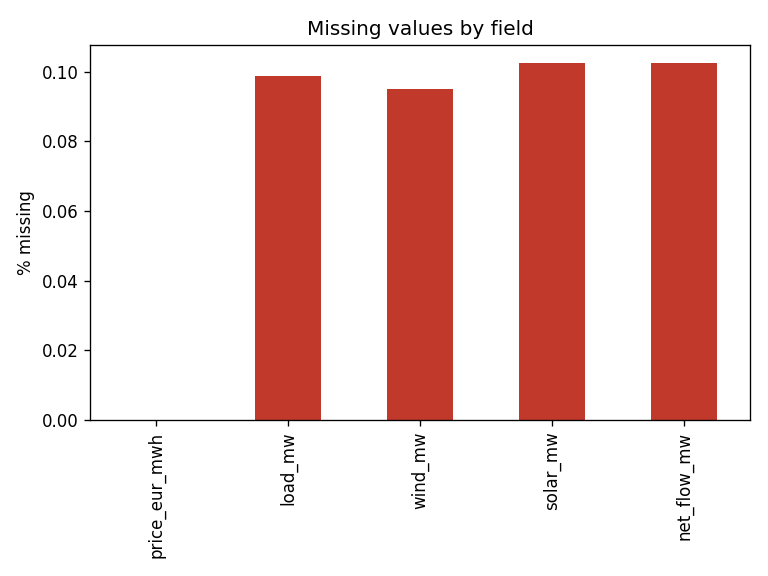

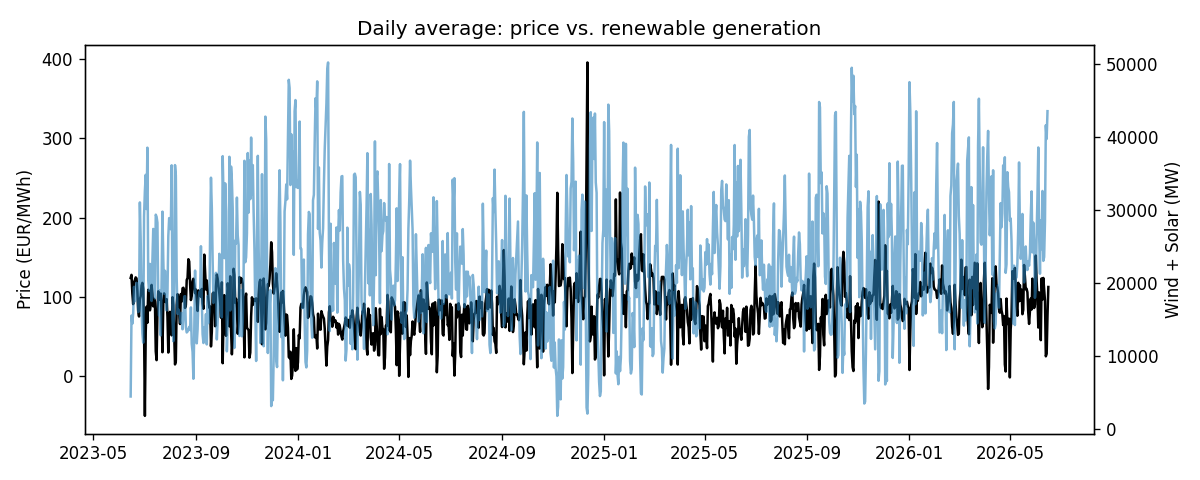

In [9]:
from IPython.display import Image, display
display(Image(str(config.FIGURE_DIR / "missingness.png")))
display(Image(str(config.FIGURE_DIR / "price_vs_renewables.png")))